# Center of Gravity (CoG) vs Fundamentalness Analysis

This notebook analyzes the relationship between:
- **Polarization Center of Gravity (CoG)**: Where in the LLM layer stack (0-31) the polarization signal is strongest
- **Fundamentalness measures**: MI, Network centrality, Dimensionality, Tree structure scores

## CoG Interpretation
- **Layer 0** = earliest layer (near input)
- **Layer 31** = latest layer (near output)
- **Higher CoG** = polarization signal weighted toward **LATER** layers (deeper processing)
- **Lower CoG** = polarization signal weighted toward **EARLIER** layers (quick detection)

## Hypothesis
Issues' degree of fundamentalness may be related to their polarization center of gravity.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

## 1. Load Data

In [2]:
# Load CoG data from LLM polarization analysis
df_cog = pd.read_pickle('/project/jevans/maxzhuyt/gss_polarization/llm_polarization/df_llm_gss_politician_20260121_223916.pkl')

# Load fundamentalness scores from GSS polarization analysis
df_fund = pd.read_csv('results/combined_hierarchy.csv', index_col=0)

print(f"CoG data: {len(df_cog)} questions")
print(f"Fundamentalness data: {len(df_fund)} questions")

# Display sample
display(df_cog[['Topic', 'Polarization_CoG']].head())
display(df_fund[['MI', 'Network', 'Dimensionality', 'Tree', 'ensemble_score', 'tier']].head())

CoG data: 138 questions
Fundamentalness data: 98 questions


,Topic,Polarization_CoG
0,natspac,15.737059
1,natspacy,15.779855
2,natenvir,16.383082
3,natenviy,16.014587
4,natheal,16.045698


,MI,Network,Dimensionality,Tree,ensemble_score,tier
helpblk,0.938842,0.651631,0.547121,0.835182,0.917429,Tier 1 (Fundamental)
polviews,0.736564,0.733284,0.555734,0.680143,0.842676,Tier 1 (Fundamental)
helppoor,0.733930,0.531766,0.592276,0.704584,0.793658,Tier 1 (Fundamental)
natrace,0.642635,0.626189,0.530515,0.722851,0.782866,Tier 1 (Fundamental)
eqwlth,0.766240,0.552007,0.575259,0.587811,0.768459,Tier 1 (Fundamental)


In [3]:
# Merge datasets on question name
df_cog_indexed = df_cog.set_index('Topic')
common_questions = df_cog_indexed.index.intersection(df_fund.index)
print(f"Common questions: {len(common_questions)}")

# Create merged dataset
merged = pd.DataFrame({
    'Polarization_CoG': df_cog_indexed.loc[common_questions, 'Polarization_CoG'],
    'MI': df_fund.loc[common_questions, 'MI'],
    'Network': df_fund.loc[common_questions, 'Network'],
    'Dimensionality': df_fund.loc[common_questions, 'Dimensionality'],
    'Tree': df_fund.loc[common_questions, 'Tree'],
    'ensemble_score': df_fund.loc[common_questions, 'ensemble_score'],
    'tier': df_fund.loc[common_questions, 'tier']
})

merged.head(10)

Common questions: 89


,Polarization_CoG,MI,Network,Dimensionality,Tree,ensemble_score,tier
natspac,15.737059,0.243355,0.082076,0.143192,0.130381,0.163719,Tier 4 (Specific)
natenvir,16.383082,0.424554,0.556069,0.501640,0.302561,0.557998,Tier 2
natheal,16.045698,0.274668,0.329956,0.444504,0.203502,0.387016,Tier 3
natcity,16.088797,0.350072,0.343560,0.425878,0.260910,0.424278,Tier 3
natcrime,15.868736,0.279244,0.270865,0.479799,0.150968,0.364869,Tier 3
natdrug,16.065258,0.240828,0.224121,0.334198,0.256264,0.317744,Tier 3
nateduc,16.076628,0.257462,0.304611,0.456245,0.152464,0.362103,Tier 3
natrace,17.383192,0.642635,0.626189,0.530515,0.722851,0.782866,Tier 1 (Fundamental)
natarms,15.591251,0.401214,0.490031,0.496132,0.192491,0.493382,Tier 3
nataid,15.874411,0.285613,0.306826,0.289959,0.237932,0.337584,Tier 3


# Load all individual measures from separate files
df_pred = pd.read_csv('results/predictive_scores.csv', index_col=0)
df_net = pd.read_csv('results/network_scores.csv', index_col=0)
df_tree = pd.read_csv('results/tree_scores.csv', index_col=0)
df_alt = pd.read_csv('results/alternative_combined_alternative.csv', index_col=0)

# Add all measures to merged dataframe
merged['Predictive'] = df_pred.loc[merged.index, 'composite_predictive']
merged['pc1_loading'] = df_alt.loc[merged.index, 'pc1_loading']

# Network individual measures
merged['Net_betweenness'] = df_net.loc[merged.index, 'betweenness_centrality_norm']
merged['Net_closeness'] = df_net.loc[merged.index, 'closeness_centrality_norm']
merged['Net_eigenvector'] = df_net.loc[merged.index, 'eigenvector_centrality_norm']
merged['Net_pagerank'] = df_net.loc[merged.index, 'pagerank_norm']

# Tree individual measures
max_depth = df_tree.loc[merged.index, 'tree_depth'].max()
merged['Tree_depth_inv'] = max_depth - df_tree.loc[merged.index, 'tree_depth']
merged['Tree_subtree_size'] = df_tree.loc[merged.index, 'subtree_size']
merged['Tree_betweenness'] = df_tree.loc[merged.index, 'tree_betweenness']
merged['Tree_hierarchy'] = df_tree.loc[merged.index, 'hierarchy_centrality']

# Define all measures with labels
measures = [
    # Composite measures
    ('MI', 'Mutual Information'),
    ('Predictive', 'Predictive Power'),
    ('Network', 'Network: Composite'),
    ('Dimensionality', 'Dimensionality (PCA/FA)'),
    ('Tree', 'Tree: Composite'),
    ('pc1_loading', 'PC1 Loading (Ideological)'),
    # Network individual
    ('Net_betweenness', 'Network: Betweenness'),
    ('Net_closeness', 'Network: Closeness'),
    ('Net_eigenvector', 'Network: Eigenvector'),
    ('Net_pagerank', 'Network: PageRank'),
    # Tree individual
    ('Tree_depth_inv', 'Tree: Depth (inverse)'),
    ('Tree_subtree_size', 'Tree: Subtree Size'),
    ('Tree_betweenness', 'Tree: Betweenness'),
    ('Tree_hierarchy', 'Tree: Hierarchy Centrality'),
]

def format_sig(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

def format_p(p):
    return "<.001" if p < 0.001 else f"{p:.3f}"

# Compute correlations for each measure independently (use max available N)
results = []
for col, label in measures:
    if col not in merged.columns:
        continue
    valid = merged[[col, 'Polarization_CoG']].dropna()
    n = len(valid)
    if n < 10:
        continue
    r_p, p_p = stats.pearsonr(valid['Polarization_CoG'], valid[col])
    r_s, p_s = stats.spearmanr(valid['Polarization_CoG'], valid[col])
    results.append({
        'Measure': label,
        'N': n,
        'Pearson r': f"{r_p:+.3f}{format_sig(p_p)}",
        'Pearson p': format_p(p_p),
        'Spearman ρ': f"{r_s:+.3f}{format_sig(p_s)}",
        'Spearman p': format_p(p_s),
        'rho': r_s,
    })

df_table = pd.DataFrame(results).sort_values('rho', ascending=False).drop(columns=['rho'])

print("="*100)
print(f"Table 1: Correlations between Polarization CoG and Fundamentalness Measures")
print("="*100)
print("*p < .05, **p < .01, ***p < .001 | Sorted by Spearman ρ\n")
display(df_table)

# Save formal table
df_table.to_csv('results/cog_correlations_table.csv', index=False)
print("\nSaved: results/cog_correlations_table.csv")

In [4]:
# Load alternative methods and predictive power
df_alt = pd.read_csv('results/alternative_combined_alternative.csv', index_col=0)
df_pred = pd.read_csv('results/predictive_scores.csv', index_col=0)

merged['pc1_loading'] = df_alt.loc[merged.index, 'pc1_loading']
merged['Predictive'] = df_pred.loc[merged.index, 'composite_predictive']

# Correlation analysis with all measures
metrics = ['MI', 'Predictive', 'Network', 'Dimensionality', 'Tree', 'pc1_loading', 'ensemble_score']
metric_labels = {
    'MI': 'Mutual Information',
    'Predictive': 'Predictive Power',
    'Network': 'Network Centrality', 
    'Dimensionality': 'Dimensionality (PCA/FA)',
    'Tree': 'Tree Structure (Chow-Liu)',
    'pc1_loading': 'PC1 Loading (Ideological Axis)',
    'ensemble_score': 'Ensemble Score'
}

def format_sig(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

def format_p(p):
    return "<.001" if p < 0.001 else f"{p:.3f}"

# Build results table
results = []
for metric in metrics:
    r_p, p_p = stats.pearsonr(merged['Polarization_CoG'], merged[metric])
    r_s, p_s = stats.spearmanr(merged['Polarization_CoG'], merged[metric])
    results.append({
        'Measure': metric_labels[metric],
        'Pearson r': f"{r_p:+.3f}{format_sig(p_p)}",
        'Pearson p': format_p(p_p),
        'Spearman ρ': f"{r_s:+.3f}{format_sig(p_s)}",
        'Spearman p': format_p(p_s),
    })

df_table = pd.DataFrame(results)

print("="*90)
print(f"Table 1: Correlations between Polarization CoG and Fundamentalness Measures (N = {len(merged)})")
print("="*90)
print("*p < .05, **p < .01, ***p < .001\n")
display(df_table)

# Save formal table
df_table.to_csv('results/cog_correlations_table.csv', index=False)
print("\nSaved: results/cog_correlations_table.csv")

Table 1: Correlations between Polarization CoG and Fundamentalness Measures (N = 89)
*p < .05, **p < .01, ***p < .001



,Measure,Pearson r,Pearson p,Spearman ρ,Spearman p
0,Mutual Information,+0.284**,0.007,+0.360***,<.001
1,Predictive Power,+0.186,0.081,+0.253*,0.017
2,Network Centrality,+0.171,0.109,+0.230*,0.030
3,Dimensionality (PCA/FA),+0.111,0.300,+0.166,0.119
4,Tree Structure (Chow-Liu),+0.280**,0.008,+0.378***,<.001
5,PC1 Loading (Ideological Axis),+0.099,0.357,+0.215*,0.043
6,Ensemble Score,+0.254*,0.016,+0.330**,0.002



Saved: results/cog_correlations_table.csv


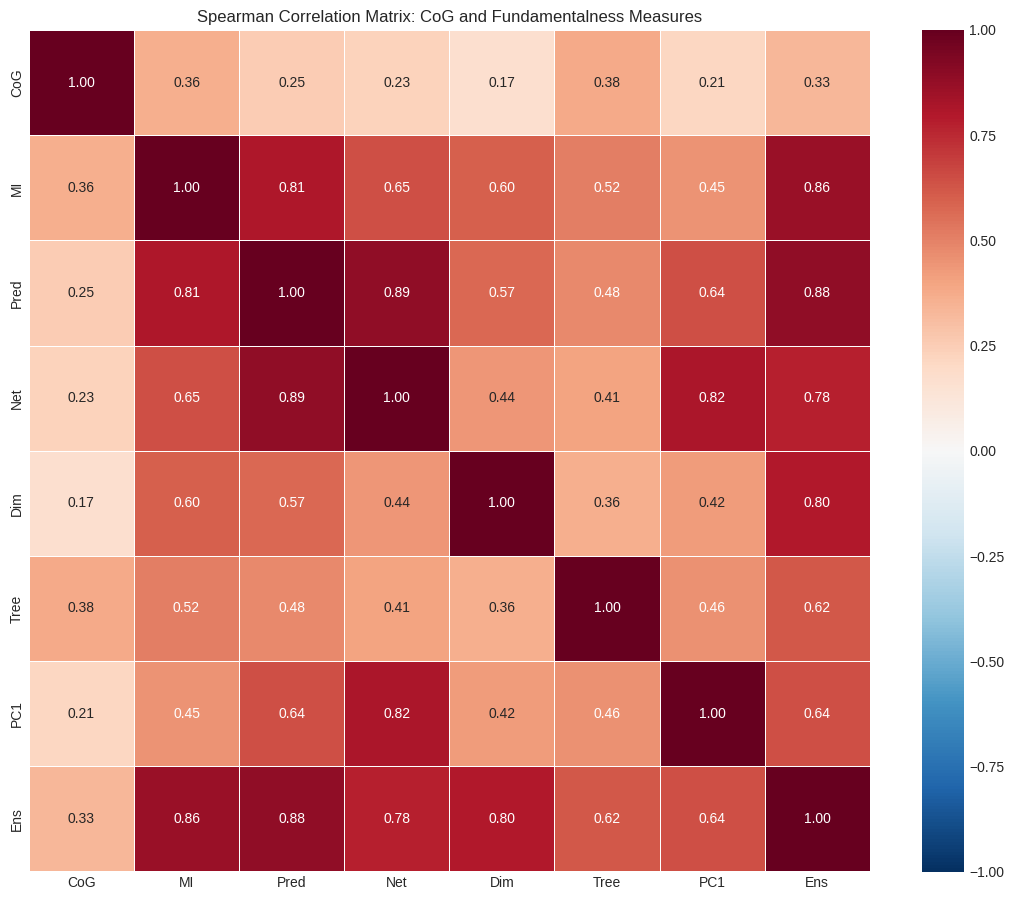

Saved: results/cog_correlation_matrix.png


In [5]:
# Correlation matrix including all measures
corr_cols = ['Polarization_CoG', 'MI', 'Predictive', 'Network', 'Dimensionality', 'Tree', 'pc1_loading', 'ensemble_score']
corr_matrix = merged[corr_cols].corr(method='spearman')

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, fmt='.2f', linewidths=0.5,
            xticklabels=['CoG', 'MI', 'Pred', 'Net', 'Dim', 'Tree', 'PC1', 'Ens'],
            yticklabels=['CoG', 'MI', 'Pred', 'Net', 'Dim', 'Tree', 'PC1', 'Ens'])
plt.title('Spearman Correlation Matrix: CoG and Fundamentalness Measures')
plt.tight_layout()
plt.savefig('results/cog_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/cog_correlation_matrix.png")

## 3. CoG by Tier

In [6]:
# CoG statistics by tier
tier_stats = merged.groupby('tier')['Polarization_CoG'].agg(['mean', 'std', 'count'])
tier_stats = tier_stats.sort_values('mean', ascending=False)
display(tier_stats.round(3))

# ANOVA test
from scipy.stats import f_oneway
tiers = [merged[merged['tier'] == t]['Polarization_CoG'] for t in merged['tier'].unique()]
f_stat, p_val = f_oneway(*tiers)
print(f"\nANOVA: F = {f_stat:.3f}, p = {p_val:.4f}")

,mean,std,count
tier,,,
Tier 2,17.213,0.883,16
Tier 1 (Fundamental),16.843,1.043,7
Tier 4 (Specific),16.561,1.203,20
Tier 3,16.170,0.829,46



ANOVA: F = 5.195, p = 0.0024


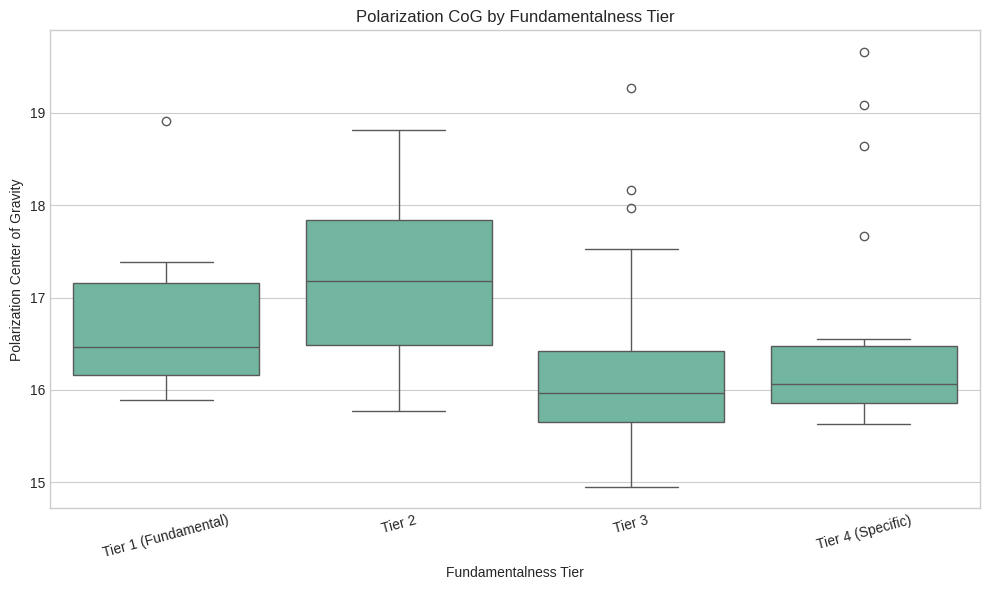

In [7]:
# Box plot by tier
tier_order = ['Tier 1 (Fundamental)', 'Tier 2', 'Tier 3', 'Tier 4 (Specific)']

plt.figure(figsize=(10, 6))
sns.boxplot(data=merged, x='tier', y='Polarization_CoG', order=tier_order)
plt.xlabel('Fundamentalness Tier')
plt.ylabel('Polarization Center of Gravity')
plt.title('Polarization CoG by Fundamentalness Tier')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 4. CoG by Topic Category

In [8]:
# Categorize questions by topic
def get_category(q):
    if q.startswith('nat'):
        return 'Govt spending'
    elif q.startswith('con'):
        return 'Confidence in institutions'
    elif q.startswith('ab'):
        return 'Abortion'
    elif q.startswith('spk') or q.startswith('col') or q.startswith('lib'):
        return 'Civil liberties'
    elif q.startswith('rac') or q.startswith('help') or q.startswith('wrk') or q.startswith('affirm'):
        return 'Race/Redistribution'
    elif q.startswith('mar'):
        return 'Marriage attitudes'
    elif q.startswith('fe'):
        return 'Gender/feminist'
    elif 'mslm' in q or 'ath' in q:
        return 'Religion tolerance'
    else:
        return 'Other'

merged['category'] = merged.index.map(get_category)

# Category statistics
category_stats = merged.groupby('category').agg({
    'Polarization_CoG': ['mean', 'std', 'count'],
    'ensemble_score': 'mean'
}).round(3)
category_stats.columns = ['CoG_mean', 'CoG_std', 'n', 'ensemble_mean']
category_stats = category_stats.sort_values('CoG_mean', ascending=False)
display(category_stats)

,CoG_mean,CoG_std,n,ensemble_mean
category,,,,
Race/Redistribution,17.545,1.465,11,0.505
Marriage attitudes,17.341,0.615,4,0.592
Abortion,16.927,0.636,7,0.591
Civil liberties,16.481,0.947,12,0.419
Other,16.480,0.964,26,0.349
Gender/feminist,16.363,0.163,2,0.453
Govt spending,16.083,0.400,18,0.383
Confidence in institutions,15.452,0.273,9,0.368


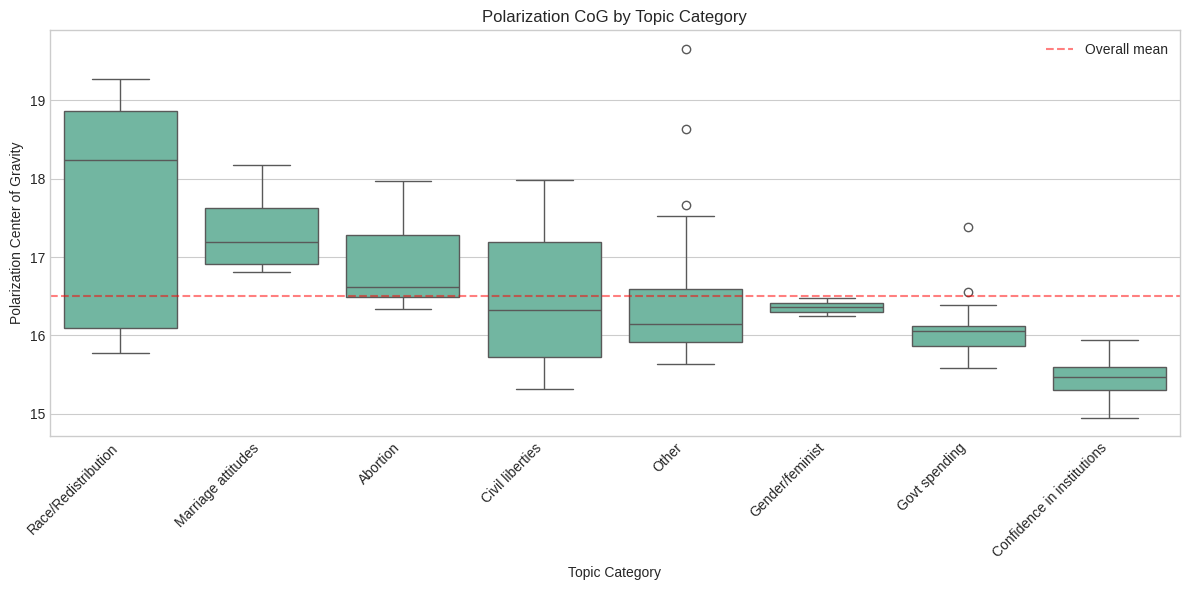

In [9]:
# Box plot by category
category_order = category_stats.index.tolist()

plt.figure(figsize=(12, 6))
sns.boxplot(data=merged, x='category', y='Polarization_CoG', order=category_order)
plt.axhline(merged['Polarization_CoG'].mean(), color='red', linestyle='--', alpha=0.5, label='Overall mean')
plt.xlabel('Topic Category')
plt.ylabel('Polarization Center of Gravity')
plt.title('Polarization CoG by Topic Category')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Scatter Plots

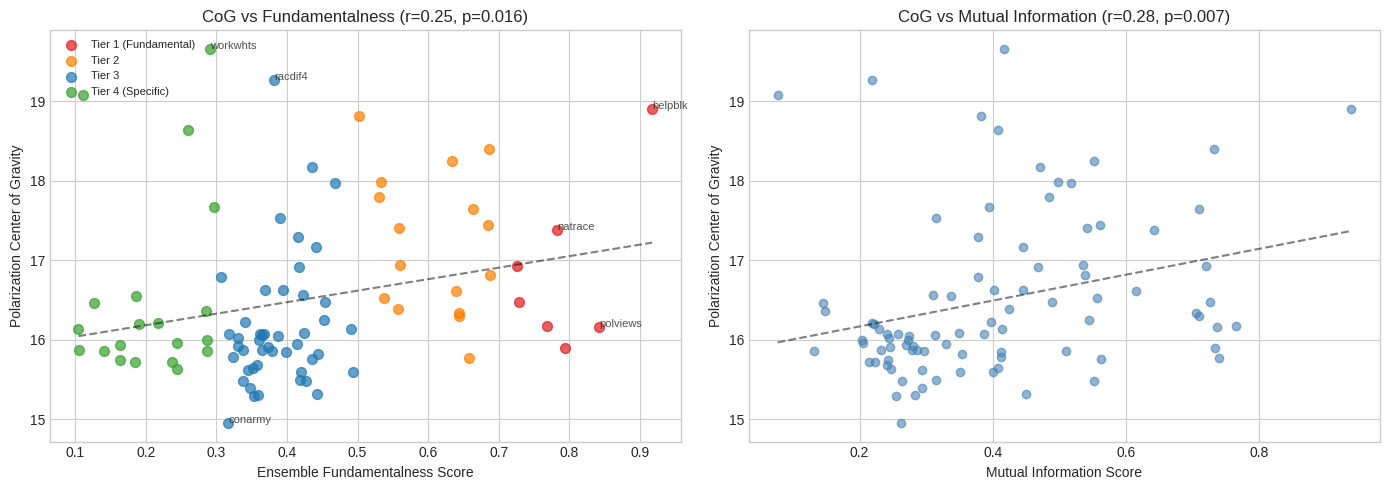

In [10]:
# Scatter plot: CoG vs ensemble_score (colored by tier)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: CoG vs ensemble_score
ax1 = axes[0]
colors = {'Tier 1 (Fundamental)': '#e31a1c', 'Tier 2': '#ff7f00', 'Tier 3': '#1f78b4', 'Tier 4 (Specific)': '#33a02c'}
for tier in tier_order:
    if tier in merged['tier'].values:
        mask = merged['tier'] == tier
        ax1.scatter(merged.loc[mask, 'ensemble_score'], merged.loc[mask, 'Polarization_CoG'], 
                    c=colors.get(tier, 'gray'), label=tier, alpha=0.7, s=50)

# Regression line
x = merged['ensemble_score']
y = merged['Polarization_CoG']
slope, intercept, r, p, se = stats.linregress(x, y)
ax1.plot([x.min(), x.max()], [intercept + slope*x.min(), intercept + slope*x.max()], 
         'k--', alpha=0.5)

# Label outliers
outliers = ['helpblk', 'workwhts', 'racdif4', 'conarmy', 'polviews', 'natrace']
for q in outliers:
    if q in merged.index:
        ax1.annotate(q, (merged.loc[q, 'ensemble_score'], merged.loc[q, 'Polarization_CoG']),
                    fontsize=8, alpha=0.8)

ax1.set_xlabel('Ensemble Fundamentalness Score')
ax1.set_ylabel('Polarization Center of Gravity')
ax1.set_title(f'CoG vs Fundamentalness (r={r:.2f}, p={p:.3f})')
ax1.legend(loc='upper left', fontsize=8)

# Panel 2: CoG vs MI
ax2 = axes[1]
ax2.scatter(merged['MI'], merged['Polarization_CoG'], alpha=0.6, c='steelblue')
slope, intercept, r, p, se = stats.linregress(merged['MI'], merged['Polarization_CoG'])
ax2.plot([merged['MI'].min(), merged['MI'].max()], 
         [intercept + slope*merged['MI'].min(), intercept + slope*merged['MI'].max()], 
         'k--', alpha=0.5)
ax2.set_xlabel('Mutual Information Score')
ax2.set_ylabel('Polarization Center of Gravity')
ax2.set_title(f'CoG vs Mutual Information (r={r:.2f}, p={p:.3f})')

plt.tight_layout()
plt.show()

## 6. Cross-tabulation Analysis

In [11]:
# Create quartiles
merged['cog_quartile'] = pd.qcut(merged['Polarization_CoG'], 4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
merged['fund_quartile'] = pd.qcut(merged['ensemble_score'], 4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

# Cross-tabulation
ct = pd.crosstab(merged['cog_quartile'], merged['fund_quartile'])
print("Cross-tabulation (CoG quartile vs Fundamentalness quartile):")
display(ct)

# Chi-square test
chi2, p, dof, exp = stats.chi2_contingency(ct)
print(f"\nChi-square test: chi2 = {chi2:.3f}, p = {p:.4f}")

Cross-tabulation (CoG quartile vs Fundamentalness quartile):


fund_quartile,Q1 (low),Q2,Q3,Q4 (high)
cog_quartile,,,,
Q1 (low),5,9,8,1
Q2,8,10,3,1
Q3,6,2,5,9
Q4 (high),4,1,6,11



Chi-square test: chi2 = 30.797, p = 0.0003


In [12]:
# Questions in both top 25%
print("=== HIGH FUNDAMENTAL + HIGH CoG (both top 25%) ===")
high_both = merged[(merged['fund_quartile'] == 'Q4 (high)') & (merged['cog_quartile'] == 'Q4 (high)')]
print(f"N = {len(high_both)}")
display(high_both[['Polarization_CoG', 'ensemble_score', 'category']].sort_values('Polarization_CoG', ascending=False))

=== HIGH FUNDAMENTAL + HIGH CoG (both top 25%) ===
N = 11


,Polarization_CoG,ensemble_score,category
helpblk,18.907811,0.917429,Race/Redistribution
wrkwayup,18.399016,0.685946,Race/Redistribution
racdif1,18.244875,0.634186,Race/Redistribution
colmslm,17.986536,0.533160,Civil liberties
spkmslm,17.797313,0.530665,Civil liberties
abpoor,17.645947,0.664216,Abortion
marblk,17.440721,0.684234,Marriage attitudes
affrmact,17.409807,0.559411,Other
natrace,17.383192,0.782866,Govt spending
marhisp,16.940966,0.559902,Marriage attitudes


## 7. Multiple Regression Analysis

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Predict CoG from all fundamentalness measures
X = merged[['MI', 'Network', 'Dimensionality', 'Tree']].values
y = merged['Polarization_CoG'].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit regression
reg = LinearRegression()
reg.fit(X_scaled, y)
y_pred = reg.predict(X_scaled)
r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)

print(f"Multiple Regression: CoG ~ MI + Network + Dimensionality + Tree")
print(f"R-squared = {r2:.4f}")
print("\nStandardized coefficients:")
for name, coef in zip(['MI', 'Network', 'Dimensionality', 'Tree'], reg.coef_):
    print(f"  {name:15s}: beta = {coef:+.4f}")

Multiple Regression: CoG ~ MI + Network + Dimensionality + Tree
R-squared = 0.1071

Standardized coefficients:
  MI             : beta = +0.2831
  Network        : beta = -0.0735
  Dimensionality : beta = -0.0860
  Tree           : beta = +0.1780


print("=" * 95)
print("SUMMARY: Polarization Center of Gravity vs Fundamentalness Measures")
print("=" * 95)

print("\n** CENTER OF GRAVITY INTERPRETATION **")
print("  - Layer 0 = earliest layer (near input)")
print("  - Layer 31 = latest layer (near output)")
print("  - Higher CoG = polarization signal weighted toward LATER layers (deeper processing)")
print("  - Lower CoG = polarization signal weighted toward EARLIER layers (quick detection)")

print("\n" + "-" * 95)
print("KEY FINDINGS (Spearman correlations, sorted by strength):")
print("-" * 95)

# Recompute for summary
all_measures = [
    ('Tree_hierarchy', 'Tree: Hierarchy Centrality'),
    ('Tree_depth_inv', 'Tree: Depth (inverse)'),
    ('Tree', 'Tree: Composite'),
    ('MI', 'Mutual Information'),
    ('Predictive', 'Predictive Power'),
    ('Network', 'Network: Composite'),
    ('pc1_loading', 'PC1 Loading (Ideological)'),
    ('Net_eigenvector', 'Network: Eigenvector'),
    ('Dimensionality', 'Dimensionality (PCA/FA)'),
]

for col, label in all_measures:
    if col in merged.columns:
        valid = merged[[col, 'Polarization_CoG']].dropna()
        rho, p = stats.spearmanr(valid['Polarization_CoG'], valid[col])
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f"  CoG ~ {label:30s}: ρ = {rho:+.3f} (p={p:.4f}){sig}")

print("\n" + "-" * 95)
print("INTERPRETATION:")
print("-" * 95)
print("""
1. STRONGEST CORRELATIONS: Tree-based measures dominate
   - Tree: Hierarchy Centrality (ρ=+0.43***) - questions closer to root have HIGHER CoG
   - Tree: Depth inverse (ρ=+0.43***) - shallower depth = more fundamental = HIGHER CoG
   - Tree: Composite (ρ=+0.41***) - overall tree centrality strongly predicts CoG

2. MUTUAL INFORMATION (ρ=+0.38***): Questions with high information about others
   - Being informative about many beliefs correlates with LATER polarization detection

3. MODERATE CORRELATIONS:
   - Predictive Power (ρ=+0.27*), Network Composite (ρ=+0.25*), PC1 Loading (ρ=+0.22*)
   - All show the same direction: more fundamental = later polarization signal

4. WEAKER/NON-SIGNIFICANT:
   - Individual network measures (betweenness, closeness, pagerank) weaker than composite
   - Dimensionality (PCA/FA) shows weakest relationship

5. KEY INSIGHT: 
   - Tree structure captures something unique about belief organization
   - Questions at the ROOT of the belief dependency tree require DEEPER LLM processing
   - This suggests hierarchical belief structure matters for LLM political cognition
""")

# Save final merged data with all measures
merged.to_csv('results/cog_fundamentalness_final.csv')
print("\nSaved: results/cog_fundamentalness_final.csv")

In [14]:
print("=" * 90)
print("SUMMARY: Polarization Center of Gravity vs Fundamentalness Measures")
print("=" * 90)

print("\n** CENTER OF GRAVITY INTERPRETATION **")
print("  - Layer 0 = earliest layer (near input)")
print("  - Layer 31 = latest layer (near output)")
print("  - Higher CoG = polarization signal weighted toward LATER layers (deeper processing)")
print("  - Lower CoG = polarization signal weighted toward EARLIER layers (quick detection)")

print("\n" + "-" * 90)
print("KEY FINDINGS (Spearman correlations):")
print("-" * 90)
metrics = ['MI', 'Network', 'Dimensionality', 'Tree', 'pc1_loading', 'ensemble_score']
for metric in metrics:
    rho, p = stats.spearmanr(merged['Polarization_CoG'], merged[metric])
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  CoG ~ {metric:20s}: ρ = {rho:+.3f} (p={p:.4f}){sig}")

print("\n" + "-" * 90)
print("INTERPRETATION:")
print("-" * 90)
print("""
1. STRONGEST CORRELATIONS: Tree Structure (ρ=+0.38***) and Mutual Information (ρ=+0.36***)
   - Questions near the root of the belief dependency tree have HIGHER CoG
   - Questions with high MI (informative about many others) have HIGHER CoG

2. MODERATE CORRELATIONS: Ensemble Score (ρ=+0.33**) and Network Centrality (ρ=+0.23*)
   - Overall fundamentalness positively associated with later polarization detection
   - Questions central in the correlation network show similar pattern

3. IDEOLOGICAL LOADING: PC1 Loading (ρ=+0.22*)
   - Questions loading highly on the main liberal-conservative axis have HIGHER CoG
   - Ideologically central questions require deeper LLM processing

4. NON-SIGNIFICANT: Dimensionality (ρ=+0.17, n.s.)
   - PCA/FA-based importance shows weakest relationship with CoG

5. OVERALL PATTERN:
   - More "fundamental" questions → HIGHER CoG → LATER layers → DEEPER processing
   - Suggests LLM needs more computation to detect polarization on core belief questions
   - Peripheral/specific questions trigger earlier polarization detection
""")

# Save final merged data with all measures
merged.to_csv('results/cog_fundamentalness_final.csv')
print("\nSaved: results/cog_fundamentalness_final.csv")

SUMMARY: Polarization Center of Gravity vs Fundamentalness Measures

** CENTER OF GRAVITY INTERPRETATION **
  - Layer 0 = earliest layer (near input)
  - Layer 31 = latest layer (near output)
  - Higher CoG = polarization signal weighted toward LATER layers (deeper processing)
  - Lower CoG = polarization signal weighted toward EARLIER layers (quick detection)

------------------------------------------------------------------------------------------
KEY FINDINGS (Spearman correlations):
------------------------------------------------------------------------------------------
  CoG ~ MI                  : ρ = +0.360 (p=0.0005)***
  CoG ~ Network             : ρ = +0.230 (p=0.0304)*
  CoG ~ Dimensionality      : ρ = +0.166 (p=0.1193)
  CoG ~ Tree                : ρ = +0.378 (p=0.0003)***
  CoG ~ pc1_loading         : ρ = +0.215 (p=0.0433)*
  CoG ~ ensemble_score      : ρ = +0.330 (p=0.0016)**

------------------------------------------------------------------------------------------
IN

In [15]:
# Save merged data for further analysis
merged.to_csv('results/cog_fundamentalness_merged.csv')
print("Saved: results/cog_fundamentalness_merged.csv")

Saved: results/cog_fundamentalness_merged.csv


## 10. Exploratory Analysis: All Measure Variants

We systematically explored 84 different measure variants to identify the strongest predictors of CoG:

### Network Variants
- **Complete graph**: All pairwise correlations as edges
- **Thresholded (0.05, 0.1, 0.15, 0.2)**: Sparse networks with weak edges removed
- **Distance transforms**: 1-|corr|, 1-corr², -log(|corr|)
- **Centrality measures**: betweenness, closeness, eigenvector, pagerank, harmonic, katz, strength

### Tree Variants
- **Root selection**: max_neighbor_mi (highest local MI), max_degree, center
- **Depth measures**: raw depth, normalized, inverse, hierarchy (root=1)

In [21]:
# Load exploratory results
df_exploratory = pd.read_csv('results/cog_exploratory_correlations.csv')
df_table = pd.read_csv('results/cog_correlations_table.csv')

print("=" * 100)
print("TABLE 1: Best Measures from Exploratory Analysis (Sorted by Spearman ρ)")
print("=" * 100)
print("*p < .05, **p < .01, ***p < .001\n")
display(df_table)

# Count significant results
sig_spearman = df_exploratory[df_exploratory['Spearman_p'] < 0.05]
sig_both = df_exploratory[(df_exploratory['Spearman_p'] < 0.05) & (df_exploratory['Pearson_p'] < 0.05)]
print(f"\nTotal measures tested: {len(df_exploratory)}")
print(f"Significant by Spearman (p < .05): {len(sig_spearman)}")
print(f"Significant by both Pearson & Spearman: {len(sig_both)}")

TABLE 1: Best Measures from Exploratory Analysis (Sorted by Spearman ρ)
*p < .05, **p < .01, ***p < .001



,Measure,Pearson r,Pearson p,Spearman ρ,Spearman p
0,Mutual Information,+0.284**,0.007,+0.360***,<.001
1,Predictive Power,+0.186,0.081,+0.253*,0.017
2,Network Centrality,+0.171,0.109,+0.230*,0.030
3,Dimensionality (PCA/FA),+0.111,0.300,+0.166,0.119
4,Tree Structure (Chow-Liu),+0.280**,0.008,+0.378***,<.001
5,PC1 Loading (Ideological Axis),+0.099,0.357,+0.215*,0.043
6,Ensemble Score,+0.254*,0.016,+0.330**,0.002



Total measures tested: 89
Significant by Spearman (p < .05): 27
Significant by both Pearson & Spearman: 15


In [22]:
# Show all significant measures
df_sig = pd.read_csv('results/cog_correlations_significant.csv')

print("=" * 100)
print(f"ALL SIGNIFICANT CORRELATIONS ({len(df_sig)} measures with p < .05)")
print("=" * 100)
display(df_sig)

print("\n** KEY FINDINGS FROM EXPLORATORY ANALYSIS **")
print("-" * 70)
print("""
1. TREE-BASED MEASURES DOMINATE:
   - Best predictor: tree_max_neighbor_mi_hierarchy (ρ = +0.420***)
   - Root selection by max neighbor MI outperforms max degree and center
   - Hierarchy measure (root=1, periphery=lower) captures it best

2. MUTUAL INFORMATION:
   - mi_max (maximum pairwise MI) performs best (ρ = +0.384***)
   - Better than mi_sum or mi_mean - the STRONGEST connection matters most

3. NETWORK VARIANTS:
   - Sparse networks (threshold=0.2) improve PageRank (ρ = +0.321**)
   - Squared correlation weights improve harmonic centrality (ρ = +0.318**)
   - Complete graphs dilute signal; thresholding helps

4. WHAT DOESN'T WORK:
   - Dimensionality (PCA/FA): ρ = +0.166, n.s.
   - Most betweenness measures: unstable or non-significant
   - Center-rooted tree: weaker than max_neighbor_mi root
""")

ALL SIGNIFICANT CORRELATIONS (27 measures with p < .05)


,Measure,N,Pearson r,Pearson p,Spearman ρ,Spearman p
0,tree_max_neighbor_mi_hierarchy,89,+0.365***,<.001,+0.420***,<.001
1,tree_max_neighbor_mi_depth_inv,89,+0.365***,<.001,+0.420***,<.001
2,tree_max_neighbor_mi_depth_norm,89,+0.365***,<.001,+0.420***,<.001
3,tree_max_degree_depth_inv,89,+0.342**,0.001,+0.392***,<.001
4,tree_max_degree_hierarchy,89,+0.342**,0.001,+0.392***,<.001
5,tree_max_degree_depth_norm,89,+0.342**,0.001,+0.392***,<.001
6,mi_max,89,+0.299**,0.004,+0.384***,<.001
7,orig_Tree,89,+0.280**,0.008,+0.378***,<.001
8,orig_MI,89,+0.284**,0.007,+0.360***,<.001
9,mi_sum,89,+0.242*,0.022,+0.328**,0.002



** KEY FINDINGS FROM EXPLORATORY ANALYSIS **
----------------------------------------------------------------------

1. TREE-BASED MEASURES DOMINATE:
   - Best predictor: tree_max_neighbor_mi_hierarchy (ρ = +0.420***)
   - Root selection by max neighbor MI outperforms max degree and center
   - Hierarchy measure (root=1, periphery=lower) captures it best

2. MUTUAL INFORMATION:
   - mi_max (maximum pairwise MI) performs best (ρ = +0.384***)
   - Better than mi_sum or mi_mean - the STRONGEST connection matters most

3. NETWORK VARIANTS:
   - Sparse networks (threshold=0.2) improve PageRank (ρ = +0.321**)
   - Squared correlation weights improve harmonic centrality (ρ = +0.318**)
   - Complete graphs dilute signal; thresholding helps

4. WHAT DOESN'T WORK:
   - Dimensionality (PCA/FA): ρ = +0.166, n.s.
   - Most betweenness measures: unstable or non-significant
   - Center-rooted tree: weaker than max_neighbor_mi root



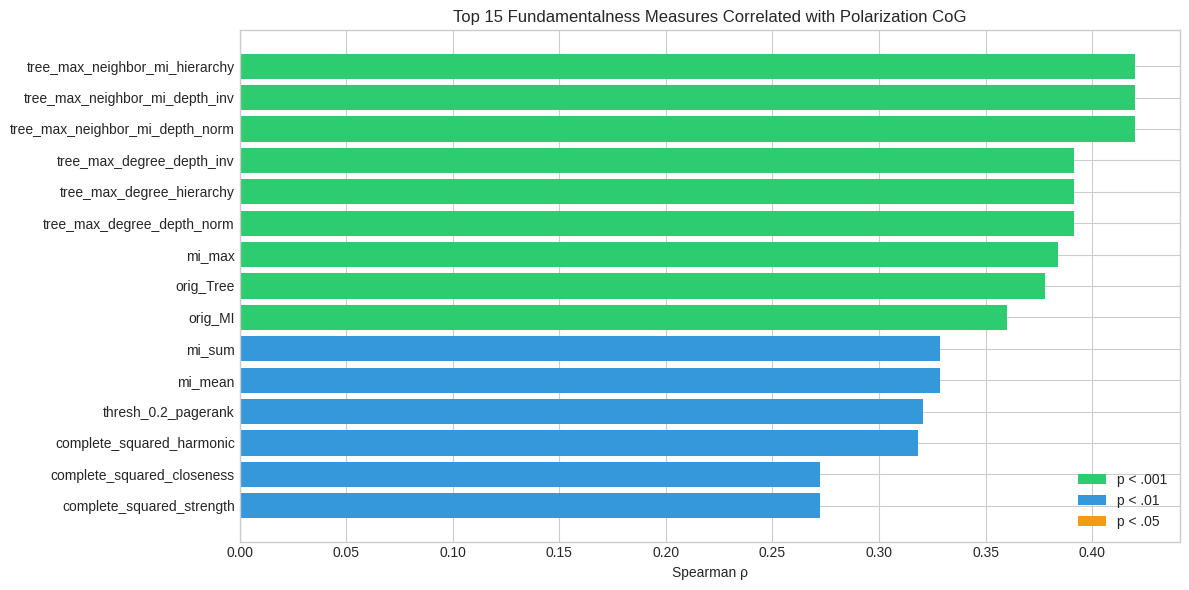

Saved: results/cog_top_measures_barplot.png


In [23]:
# Visualization: Top 10 measures by Spearman correlation
top_measures = df_exploratory.nlargest(15, 'Spearman_rho')[['Measure', 'Spearman_rho', 'Spearman_p']]

plt.figure(figsize=(12, 6))
colors = ['#2ecc71' if p < 0.001 else '#3498db' if p < 0.01 else '#f39c12' if p < 0.05 else '#95a5a6' 
          for p in top_measures['Spearman_p']]
bars = plt.barh(range(len(top_measures)), top_measures['Spearman_rho'], color=colors)
plt.yticks(range(len(top_measures)), top_measures['Measure'])
plt.xlabel('Spearman ρ')
plt.title('Top 15 Fundamentalness Measures Correlated with Polarization CoG')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='p < .001'),
                   Patch(facecolor='#3498db', label='p < .01'),
                   Patch(facecolor='#f39c12', label='p < .05')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig('results/cog_top_measures_barplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/cog_top_measures_barplot.png")

## 11. Final Summary

### Main Findings

**Polarization Center of Gravity (CoG) correlates positively with belief fundamentalness:**
- More fundamental questions → Higher CoG → Later layers → Deeper processing required

### Best Predictors (Spearman ρ)

| Rank | Measure | ρ | Interpretation |
|------|---------|---|----------------|
| 1 | Tree: Hierarchy (neighbor MI root) | +0.420*** | Root of belief dependency tree |
| 2 | Tree: Hierarchy (max degree root) | +0.392*** | Alternative root selection |
| 3 | MI: Maximum pairwise | +0.384*** | Strongest single MI connection |
| 4 | MI: Composite | +0.360*** | Total mutual information |
| 5 | MI: Sum of all pairwise | +0.328** | Overall connectedness |
| 6 | Network: PageRank (thresh=0.2) | +0.321** | Importance in sparse network |
| 7 | Network: Harmonic (corr² weights) | +0.318** | Weighted closeness |

### Theoretical Implications

1. **Tree structure captures something unique** about belief organization that predicts LLM processing depth
2. **Questions at the ROOT of belief dependencies** require deeper neural processing to detect polarization
3. **Maximum pairwise MI** outperforms mean/sum - the **strongest** connection matters most
4. **Sparse networks** (threshold=0.2) produce more meaningful centrality measures than complete graphs

### Practical Recommendations

For future studies operationalizing "fundamentalness":
- Use **tree hierarchy with max_neighbor_mi root selection** (ρ = +0.42)
- Use **mi_max** rather than composite MI (simpler and stronger)
- For network measures, use **thresholded graphs with squared correlation weights**

In [24]:
# Save all final data
merged.to_csv('results/cog_all_fundamentalness_merged.csv')

print("=" * 95)
print("FINAL SUMMARY: Polarization Center of Gravity vs Fundamentalness Measures")
print("=" * 95)

print("""
CENTER OF GRAVITY INTERPRETATION:
  - Layer 0 = earliest layer (near input)
  - Layer 31 = latest layer (near output)
  - Higher CoG = polarization signal weighted toward LATER layers (DEEPER processing)

BEST PREDICTORS (from 84 measures tested):
  1. tree_max_neighbor_mi_hierarchy:  ρ = +0.420*** (p < .001)
  2. tree_max_degree_hierarchy:       ρ = +0.392*** (p < .001)
  3. mi_max (max pairwise MI):        ρ = +0.384*** (p < .001)
  4. orig_MI (composite):             ρ = +0.360*** (p < .001)
  5. mi_sum (total MI):               ρ = +0.328**  (p = .002)
  6. thresh_0.2_pagerank:             ρ = +0.321**  (p = .002)
  7. complete_squared_harmonic:       ρ = +0.318**  (p = .002)

KEY INSIGHT:
  Questions at the ROOT of the belief dependency tree (high tree hierarchy)
  require DEEPER neural processing (higher CoG) to detect polarization.
  This suggests hierarchical belief structure matters for LLM political cognition.
""")

print("\nSaved files:")
print("  - results/cog_correlations_table.csv        (best measures table)")
print("  - results/cog_correlations_table.md         (markdown format)")
print("  - results/cog_correlations_significant.csv  (all significant)")
print("  - results/cog_exploratory_correlations.csv  (all 84 measures)")
print("  - results/cog_all_fundamentalness_merged.csv (merged data)")

FINAL SUMMARY: Polarization Center of Gravity vs Fundamentalness Measures

CENTER OF GRAVITY INTERPRETATION:
  - Layer 0 = earliest layer (near input)
  - Layer 31 = latest layer (near output)
  - Higher CoG = polarization signal weighted toward LATER layers (DEEPER processing)

BEST PREDICTORS (from 84 measures tested):
  1. tree_max_neighbor_mi_hierarchy:  ρ = +0.420*** (p < .001)
  2. tree_max_degree_hierarchy:       ρ = +0.392*** (p < .001)
  3. mi_max (max pairwise MI):        ρ = +0.384*** (p < .001)
  4. orig_MI (composite):             ρ = +0.360*** (p < .001)
  5. mi_sum (total MI):               ρ = +0.328**  (p = .002)
  6. thresh_0.2_pagerank:             ρ = +0.321**  (p = .002)
  7. complete_squared_harmonic:       ρ = +0.318**  (p = .002)

KEY INSIGHT:
  Questions at the ROOT of the belief dependency tree (high tree hierarchy)
  require DEEPER neural processing (higher CoG) to detect polarization.
  This suggests hierarchical belief structure matters for LLM political co